In [321]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_rows

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score

In [322]:
# re-import the cars dataset
cars = sns.load_dataset('mpg')
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


##### **Task 1: Identify the strongest and weakest correlations in the cars dataset**.

Notes:

<br> Strongest correlation between cylinders and displacement
<br> Cylinders, Weight, displacement and horsepower share strong correlations
<br>
<br>

<Axes: >

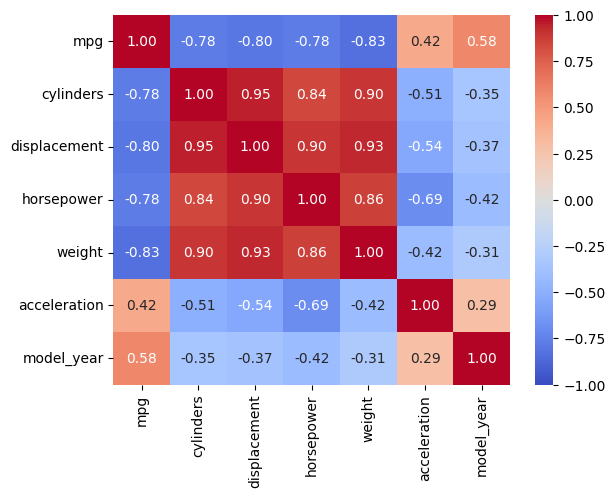

In [323]:
# select only numerical columns from cars
cars_numerical = cars.select_dtypes(include=['int64', 'float64'])

# heatmap for the cars dataset
sns.heatmap(cars_numerical.corr(), 
            cmap='coolwarm', 
            annot=True, 
            fmt=".2f", 
            vmin=-1, 
            vmax=1)

##### **Task 2: Check for multicollinearity in the cars dataset. Select the features by using the 2 learned methods:**
- by checking the Pearson coefficient. Build a model on the selected predictors
- by checking the VIF value. Compare the chosen predictors from the previous method. Build a model on the VIF predictors.

Validate the 2 models and compare their results(mean and std).

You will need to copy over your model from the last task notebook first.

In [324]:
cars = sns.load_dataset('mpg')
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [325]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [326]:
cars.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [327]:
# drop rows with missing values
cars = cars.dropna()
cars.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
 8   name          392 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 30.6 KB


In [328]:
# Define the Target and Feature variables to predict mpg
#Target variable
y = cars['mpg']

#Feature variable
X = cars[['weight', 'horsepower', 'displacement', 'cylinders', 'acceleration', 'model_year']]

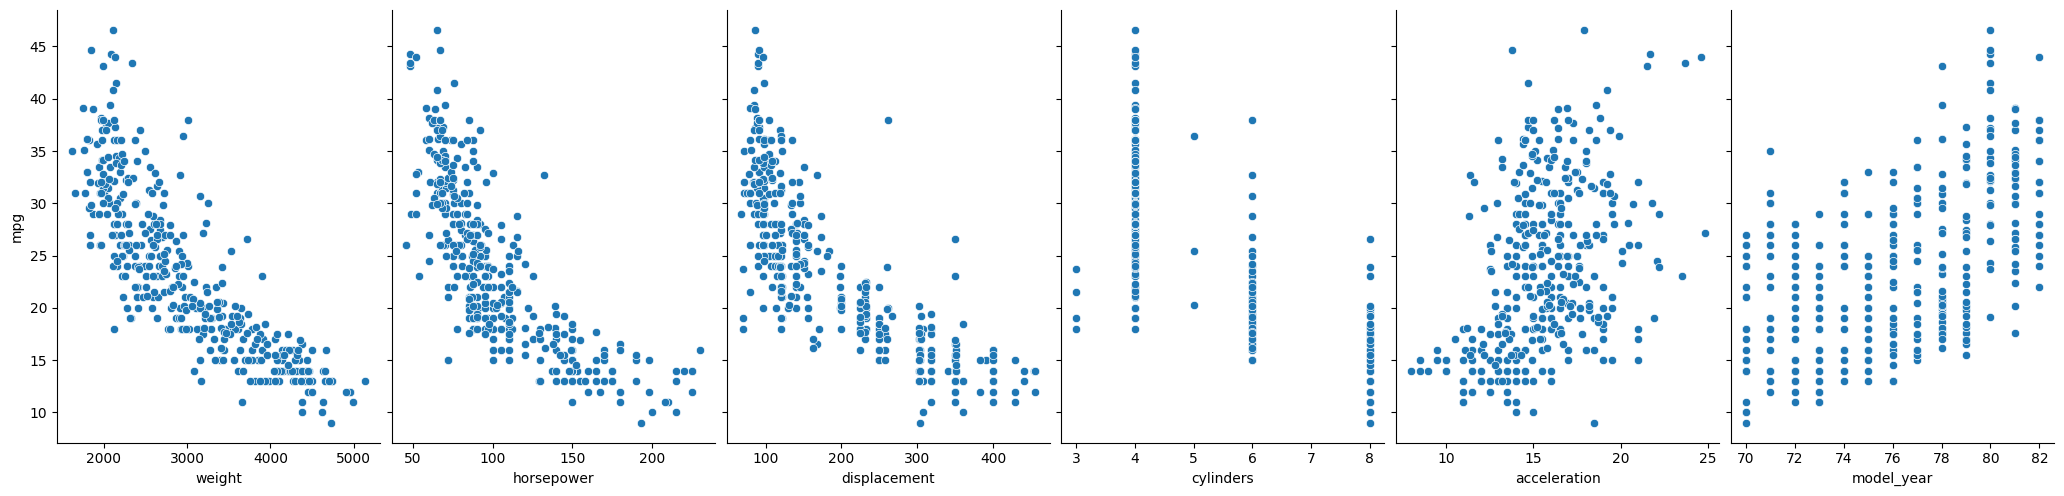

In [329]:
# Scatter each feature against the target variable
sns.pairplot(cars, x_vars=X, y_vars='mpg', height=5, aspect=0.7)
plt.show()

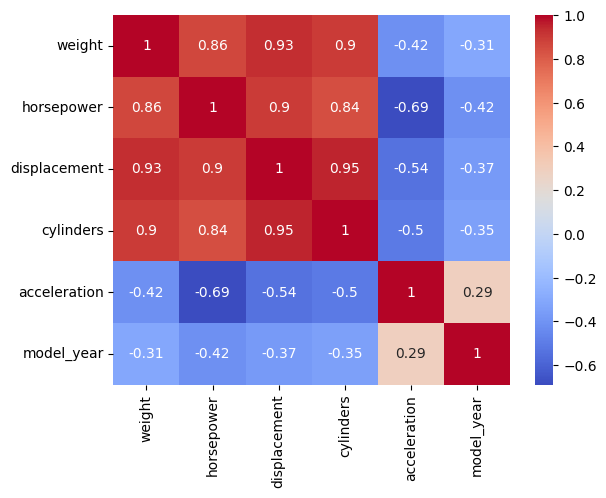

In [330]:
# View correlation matrix
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [331]:
# Pareto split data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)
X_train, X_test, y_train, y_test

(     weight  horsepower  displacement  cylinders  acceleration  model_year
 167    2171        75.0          97.0          4          16.0          75
 183    2220        81.0         116.0          4          16.9          76
 147    2108        75.0          90.0          4          15.5          74
 271    2745       105.0         156.0          4          16.7          78
 159    4657       148.0         351.0          8          13.5          75
 ..      ...         ...           ...        ...           ...         ...
 213    4055       145.0         350.0          8          12.0          76
 68     4502       155.0         350.0          8          13.5          72
 25     4615       215.0         360.0          8          14.0          70
 198    1795        53.0          91.0          4          17.4          76
 177    2694        95.0         115.0          4          15.0          75
 
 [313 rows x 6 columns],
      weight  horsepower  displacement  cylinders  accelerati

In [332]:
y_train.head() 

167    29.0
183    25.0
147    24.0
271    23.2
159    14.0
Name: mpg, dtype: float64

In [333]:
y_test.head()

240    30.5
272    23.8
215    13.0
362    24.2
58     25.0
Name: mpg, dtype: float64

In [334]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [335]:
# Coefficients of the model
model.coef_

array([-0.00654748, -0.00625999,  0.00905845, -0.45394205, -0.02675486,
        0.79155508])

In [336]:
# Intercept of the model
model.intercept_

np.float64(-15.407104281064726)

In [337]:
predicted_mpg = model.predict(X_test)
predicted_mpg

array([29.40103524, 26.19021081, 18.10077977, 27.00320748, 25.77671866,
       29.22180009, 24.44412782, 25.31972016, 27.82192117, 25.13399876,
       25.3904317 , 26.76843303, 24.93261272, 15.41806914, 12.82627115,
       21.29524604, 22.68294438, 31.63261609, 25.51403725, 20.56208272,
       29.0258836 , 33.04487349, 13.93301397, 24.86814015, 24.67042348,
       22.29967032, 12.66417299, 22.49253477, 16.80910859, 34.71386328,
       34.82242331, 34.5561723 , 11.88025416,  6.43816726, 29.46168351,
       22.51488876, 27.0145583 , 27.09676507, 16.9109    , 18.13728173,
       33.35555738, 16.44210145,  8.66067702, 28.38099886, 26.59462607,
       30.33650409, 24.22657361, 34.03016728, 28.75713702, 21.1451064 ,
       30.01123676, 26.75003992, 33.7579196 , 15.38642908, 13.06388449,
       21.7555607 , 17.62658557, 29.72962408, 16.48658917, 23.45295889,
       27.99609018, 16.41088177,  8.84606727, 30.38423216, 20.85120418,
       29.00542938, 26.29544535, 30.69385996, 25.15376401, 31.02

In [338]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error



In [339]:
# predicting the prices for the mpg from the test dataset
y_predicted = model.predict(X_test)
y_predicted

array([29.40103524, 26.19021081, 18.10077977, 27.00320748, 25.77671866,
       29.22180009, 24.44412782, 25.31972016, 27.82192117, 25.13399876,
       25.3904317 , 26.76843303, 24.93261272, 15.41806914, 12.82627115,
       21.29524604, 22.68294438, 31.63261609, 25.51403725, 20.56208272,
       29.0258836 , 33.04487349, 13.93301397, 24.86814015, 24.67042348,
       22.29967032, 12.66417299, 22.49253477, 16.80910859, 34.71386328,
       34.82242331, 34.5561723 , 11.88025416,  6.43816726, 29.46168351,
       22.51488876, 27.0145583 , 27.09676507, 16.9109    , 18.13728173,
       33.35555738, 16.44210145,  8.66067702, 28.38099886, 26.59462607,
       30.33650409, 24.22657361, 34.03016728, 28.75713702, 21.1451064 ,
       30.01123676, 26.75003992, 33.7579196 , 15.38642908, 13.06388449,
       21.7555607 , 17.62658557, 29.72962408, 16.48658917, 23.45295889,
       27.99609018, 16.41088177,  8.84606727, 30.38423216, 20.85120418,
       29.00542938, 26.29544535, 30.69385996, 25.15376401, 31.02

In [340]:
test_values = pd.DataFrame(y_test)
test_values['y_predicted'] = y_predicted
test_values

,mpg,y_predicted
240,30.5,29.401035
272,23.8,26.190211
215,13.0,18.100780
362,24.2,27.003207
58,25.0,25.776719
...,...,...
350,34.7,32.548532
134,16.0,17.830767
357,32.9,29.827414
179,22.0,22.956079


In [341]:
# Calculate MAE
mean_absolute_error(y_test, y_predicted)

2.5268071233797254

In [342]:
# Calculate MSE
mean_squared_error(y_test, y_predicted)

10.568273933786083

In [343]:
# Calculate RMSE
root_mean_squared_error(y_test, y_predicted)

3.2508881761429573

In [344]:
# Evaluate training data
model.score(X_train, y_train)

0.8073055947019079

In [345]:
# Evalute test data
model.score(X_test, y_test)

0.8101773729519801

In [346]:
from sklearn.model_selection import KFold, cross_val_score

# Define the K-Fold cross-validator
kf = KFold(n_splits=3, shuffle=True, random_state=7)
# Perform cross-validation and calculate the mean score
scores = cross_val_score(model, X, y, cv = kf, scoring = 'r2')

print(scores)
print('Mean:', scores.mean())
print('Standard deviation:', scores.std())

[0.78927027 0.78100986 0.82968734]
Mean: 0.7999891557744924
Standard deviation: 0.021268836710911405


In [347]:
model = LinearRegression()
model = model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE =', mean_absolute_error(y_test, y_predicted))
print('RMSE =', root_mean_squared_error(y_test, y_predicted))

Train r2 = 0.8073055947019079
Test r2 = 0.8101773729519801
MAE = 2.5268071233797254
RMSE = 3.2508881761429573


**Pearson Coefficient**

In [348]:
#sns.pairplot(cars)

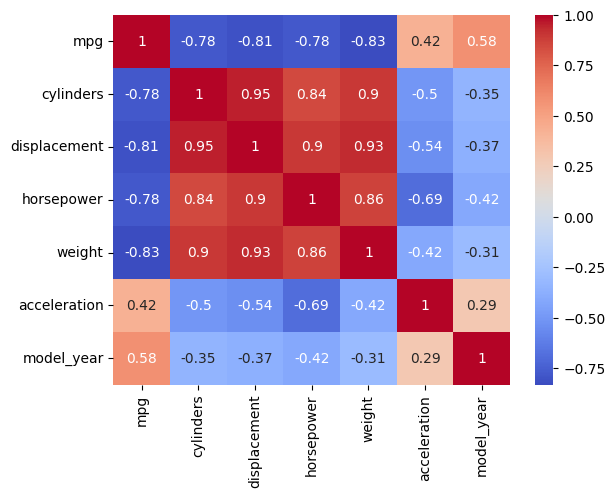

In [349]:
# View correlation matrix
# Cars Numerical data
cars_numerical = cars.select_dtypes(include=['int64', 'float64'])
correlation_matrix = cars_numerical.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()


In [350]:
corr_table = cars_numerical.corr()
corr_table

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


In [351]:
# add in .abs() to find the absolute values

corr_table['mpg'].abs().sort_values(ascending = False)

mpg             1.000000
weight          0.832244
displacement    0.805127
horsepower      0.778427
cylinders       0.777618
model_year      0.580541
acceleration    0.423329
Name: mpg, dtype: float64

In [352]:
# Check the correlation of the strongest predictor with the target variable
corr_table['weight'].abs().sort_values(ascending = False)

weight          1.000000
displacement    0.932994
cylinders       0.897527
horsepower      0.864538
mpg             0.832244
acceleration    0.416839
model_year      0.309120
Name: weight, dtype: float64

displacement is heavily correlated with weight causing multicollinearity

In [353]:
corr_table['mpg'][['weight', 'displacement']]

weight         -0.832244
displacement   -0.805127
Name: mpg, dtype: float64

In [354]:
# New model excluding displacement  
X_new = X.drop(columns=['displacement'])

In [355]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=7)
X_train, X_test, y_train, y_test

(     weight  horsepower  cylinders  acceleration  model_year
 167    2171        75.0          4          16.0          75
 183    2220        81.0          4          16.9          76
 147    2108        75.0          4          15.5          74
 271    2745       105.0          4          16.7          78
 159    4657       148.0          8          13.5          75
 ..      ...         ...        ...           ...         ...
 213    4055       145.0          8          12.0          76
 68     4502       155.0          8          13.5          72
 25     4615       215.0          8          14.0          70
 198    1795        53.0          4          17.4          76
 177    2694        95.0          4          15.0          75
 
 [313 rows x 5 columns],
      weight  horsepower  cylinders  acceleration  model_year
 240    2190        78.0          4          14.1          77
 272    2855        85.0          4          17.6          78
 215    3755       150.0          8        

In [356]:
scores_new = cross_val_score(model, X_new, y, cv=kf, scoring='r2')
print(scores_new)
print('Mean:', scores_new.mean())
print('Standard deviation:', scores_new.std())

#r2 scores for the new model
model_new = LinearRegression()  
model_new = model_new.fit(X_train, y_train)
y_predicted_new = model_new.predict(X_test)
print('Train r2 =', model_new.score(X_train, y_train))
print('Test r2 =', model_new.score(X_test, y_test))


#
#[0.78927027 0.78100986 0.82968734]
#Mean: 0.7999891557744924
#Standard deviation: 0.021268836710911405

[0.78856018 0.78511891 0.8287337 ]
Mean: 0.8008042652324824
Standard deviation: 0.01979900291386798
Train r2 = 0.8065610035238768
Test r2 = 0.8112454049644344


In [357]:
model2 = LinearRegression()
model2 = model2.fit(X_train, y_train)
y_predicted = model2.predict(X_test)

print('Train r2 =', model2.score(X_train, y_train))
print('Test r2 =', model2.score(X_test, y_test))

print('MAE =', mean_absolute_error(y_test, y_predicted))
print('RMSE =', root_mean_squared_error(y_test, y_predicted))

#PREVIOUS VALUES

#Train r2 = 0.8065610035238768
#Test r2 = 0.8112454049644344
#MAE = 2.4966400456448854
#RMSE = 3.2417297572120014

Train r2 = 0.8065610035238768
Test r2 = 0.8112454049644344
MAE = 2.4966400456448854
RMSE = 3.2417297572120014


**VIF Value**

In [358]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

features = cars.drop(columns=['mpg', 'origin','name'])
features  

,cylinders,displacement,horsepower,weight,acceleration,model_year
0,8,307.0,130.0,3504,12.0,70
1,8,350.0,165.0,3693,11.5,70
2,8,318.0,150.0,3436,11.0,70
3,8,304.0,150.0,3433,12.0,70
4,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82
394,4,97.0,52.0,2130,24.6,82
395,4,135.0,84.0,2295,11.6,82
396,4,120.0,79.0,2625,18.6,82


In [359]:
X = add_constant(features)
pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

const           753.863747
displacement     19.641683
weight           10.731681
cylinders        10.633049
horsepower        9.398043
acceleration      2.625581
model_year        1.244829
dtype: float64

In [360]:
features = features.drop(columns=['displacement'])
features        

,cylinders,horsepower,weight,acceleration,model_year
0,8,130.0,3504,12.0,70
1,8,165.0,3693,11.5,70
2,8,150.0,3436,11.0,70
3,8,150.0,3433,12.0,70
4,8,140.0,3449,10.5,70
...,...,...,...,...,...
393,4,86.0,2790,15.6,82
394,4,52.0,2130,24.6,82
395,4,84.0,2295,11.6,82
396,4,79.0,2625,18.6,82


In [361]:
X = add_constant(features)
pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

const           744.193099
horsepower        8.867796
weight            8.646446
cylinders         5.859121
acceleration      2.593284
model_year        1.238072
dtype: float64

In [362]:
features = features.drop(columns=['horsepower'])
features        

,cylinders,weight,acceleration,model_year
0,8,3504,12.0,70
1,8,3693,11.5,70
2,8,3436,11.0,70
3,8,3433,12.0,70
4,8,3449,10.5,70
...,...,...,...,...
393,4,2790,15.6,82
394,4,2130,24.6,82
395,4,2295,11.6,82
396,4,2625,18.6,82


In [363]:
X = add_constant(features)
pd.Series([variance_inflation_factor(X.values, i) 
               for i in range(X.shape[1])], 
              index=X.columns).sort_values(ascending = False)

const           576.423034
cylinders         5.823209
weight            5.190227
acceleration      1.382385
model_year        1.159545
dtype: float64

In [364]:
X_train_vif, X_test_vif, y_train_vif, y_test_vif = train_test_split(features, y, test_size=0.2, random_state=7)

vif_model = LinearRegression()
vif_model = vif_model.fit(X_train_vif, y_train_vif)
y_predicted = vif_model.predict(X_test_vif)

print('Train r2 =', vif_model.score(X_train_vif, y_train_vif))
print('Test r2 =', vif_model.score(X_test_vif, y_test_vif))

print('MAE =', mean_absolute_error(y_test_vif, y_predicted))
print('RMSE =', root_mean_squared_error(y_test_vif, y_predicted))


Train r2 = 0.8065608489583191
Test r2 = 0.8112785936990861
MAE = 2.4961143535869885
RMSE = 3.241444747889548


##### **Task 3: Describe the relationships between the target and the parameters of the cars dataset.**

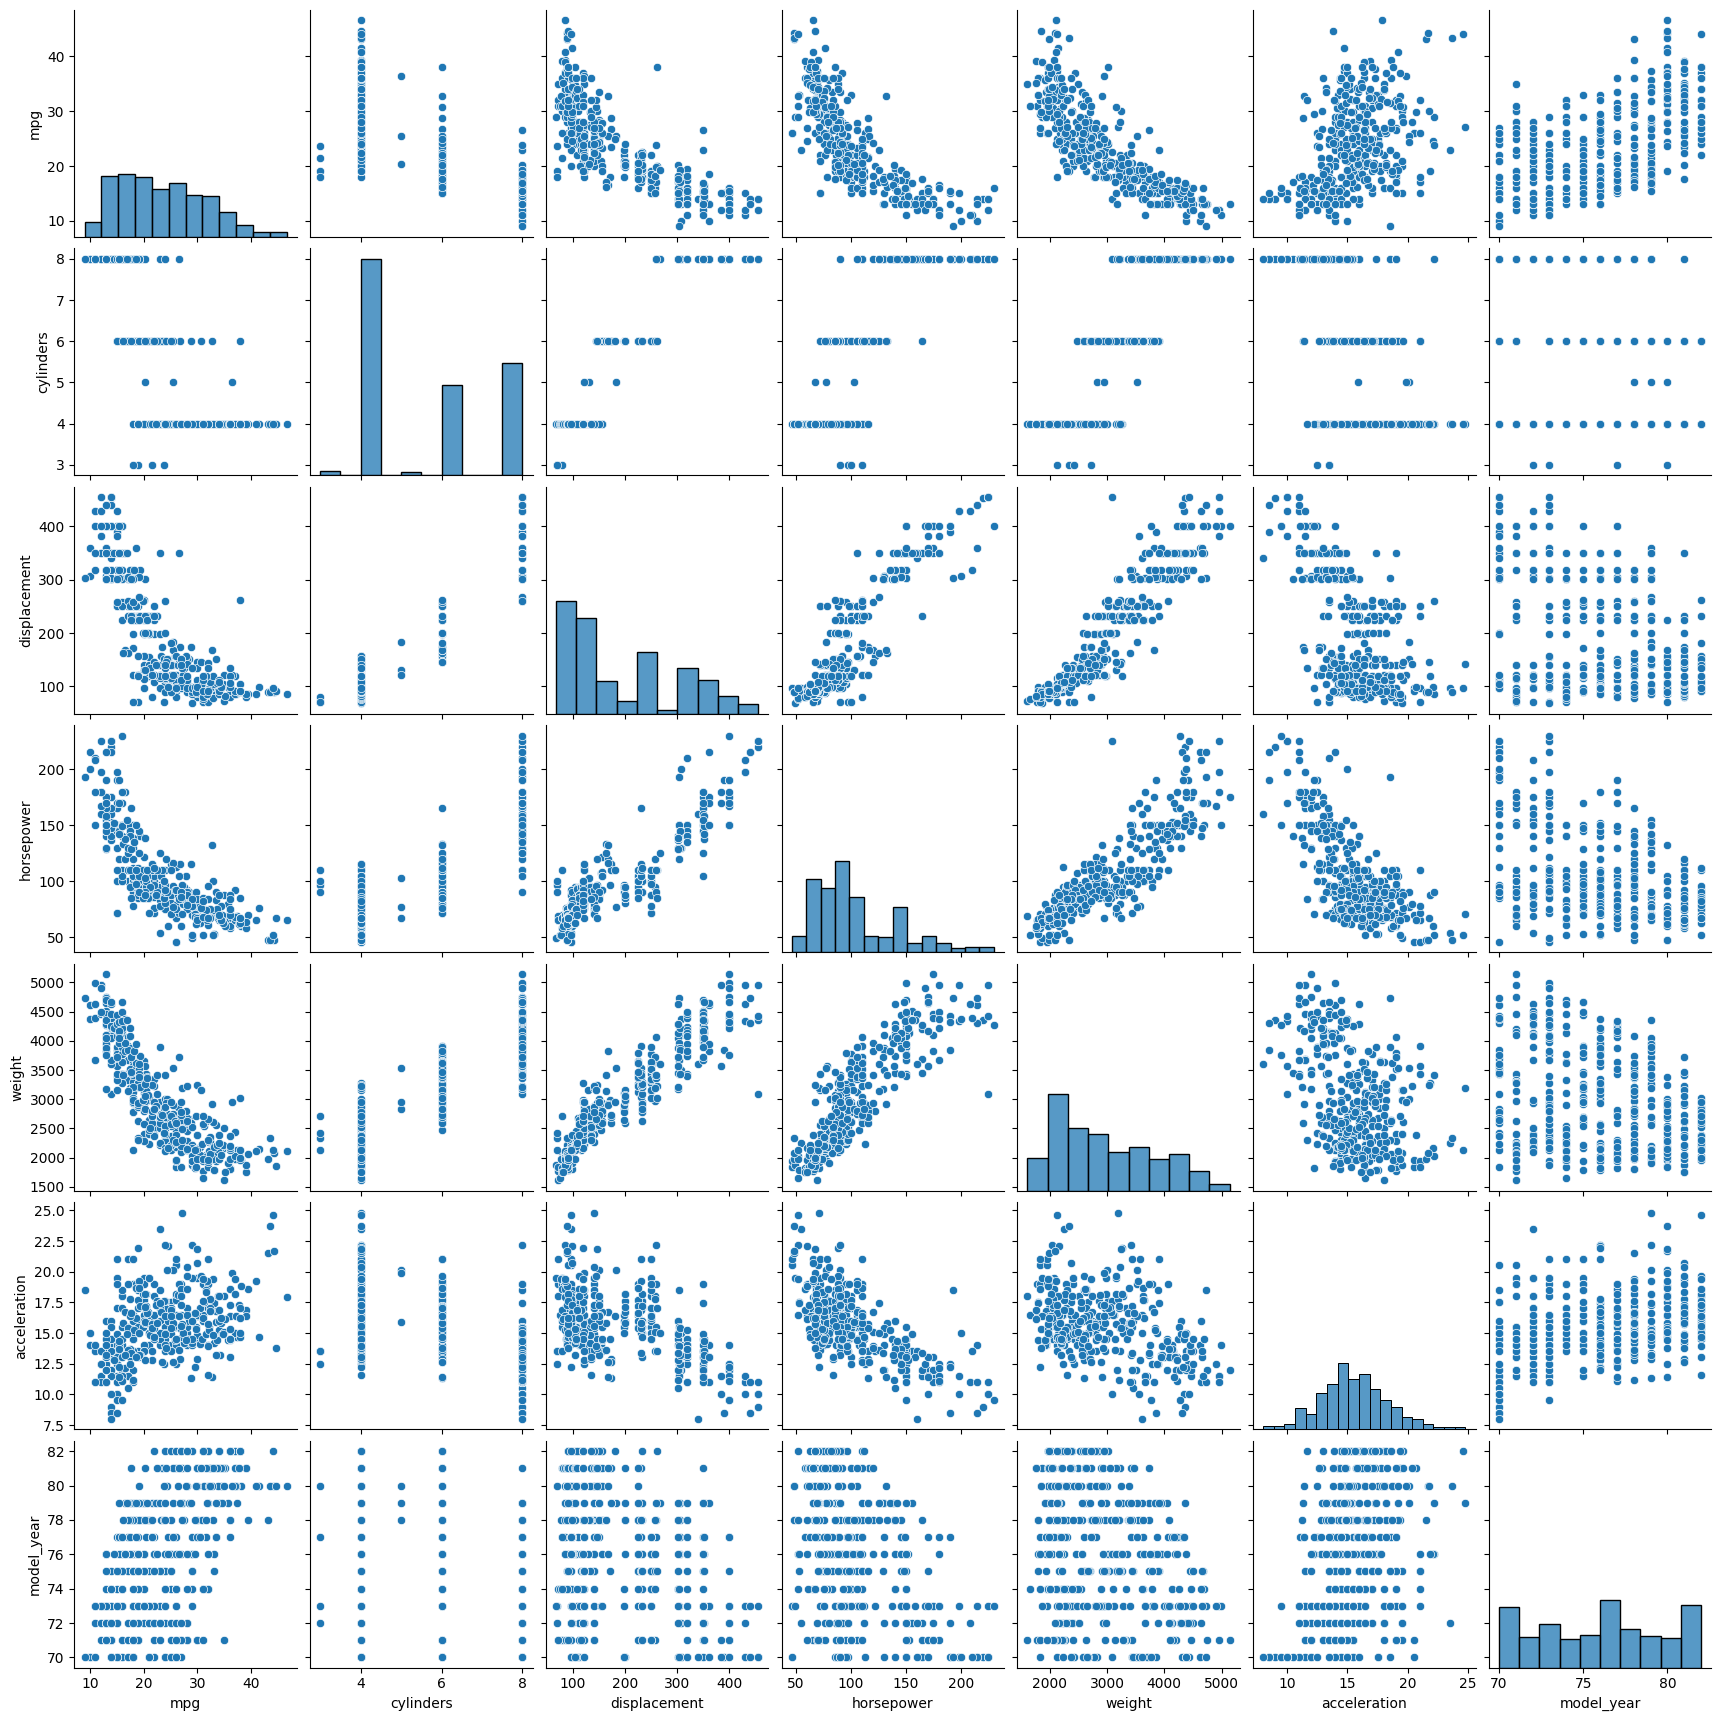

In [365]:
sns.pairplot(cars)

##### **Task 4: Find the mean of model residuals based on the cars dataset.**

In [366]:
#baseline model
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_new, y, test_size=0.2, random_state=7)
residuals_baseline = y_test_base - model_new.predict(X_test_base)
print('baseline model mean residual:', residuals_baseline.mean())

baseline model mean residual: -0.06761377859348645


In [367]:
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_new, y, test_size=0.2, random_state=7)
residuals_pearson = y_test_orig - model_new.predict(X_test_orig)
print('Pearson model mean residual:', residuals_pearson.mean())

Pearson model mean residual: -0.06761377859348645


In [368]:
X_train_vif, X_test_vif, y_train_vif, y_test_vif = train_test_split(features, y, test_size=0.2, random_state=7)
residuals_vif = y_test_vif - vif_model.predict(X_test_vif)
print('VIF model mean residual: ', residuals_vif.mean())

VIF model mean residual:  -0.06839235418054372


##### **Task 5: Check for the 'no patterns' in the model errors based on the cars dataset. Find if the error terms are homoscedastic or not.**

In [369]:
# create a table with the mpg and estimated mpg for vif model
X_train_vif2, X_test_vif2, y_train_vif2, y_test_vif2 = train_test_split(features, y, test_size=0.2, random_state=7)
estimated_mpg = vif_model.predict(X_train_vif2)

table = pd.DataFrame({'mpg': y_train_vif2})
table['estimated_mpg'] = estimated_mpg
table['errors'] = table['mpg'] - table['estimated_mpg']
table

,mpg,estimated_mpg,errors
167,29.0,27.974618,1.025382
183,25.0,28.431504,-3.431504
147,24.0,27.595047,-3.595047
271,23.2,26.725857,-3.525857
159,14.0,11.804500,2.195500
...,...,...,...
213,13.0,16.394531,-3.394531
68,13.0,10.414705,2.585295
25,10.0,8.122316,1.877684
198,33.0,31.076842,1.923158


Text(0.5, 1.0, 'Residuals vs fitted values plot for homoscedasticity check')

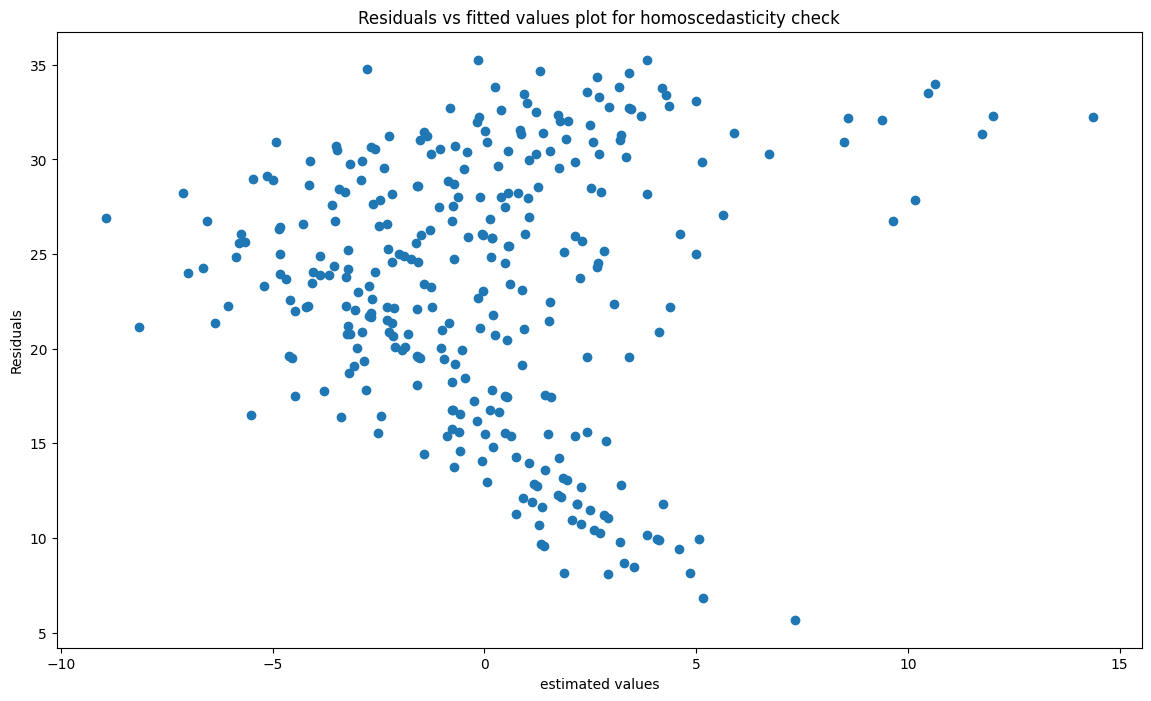

In [370]:
# create a scatterplot to check for homoscedasticity
plt.figure(figsize = (14, 8))

plt.scatter(table['errors'], table['estimated_mpg'])
plt.xlabel('estimated values')
plt.ylabel('Residuals')
plt.title('Residuals vs fitted values plot for homoscedasticity check')

In [371]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

# Conducting the Goldfeld Quandt test
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(table['errors'], X_train_vif2)
lzip(name, test)

[('F statistic', np.float64(0.6156222136212776)),
 ('p-value', np.float64(0.9985354460939873))]

##### **Task 6: Check the normality of the model residuals based on the cars dataset.**

Text(0.5, 1.0, 'Normality of error')

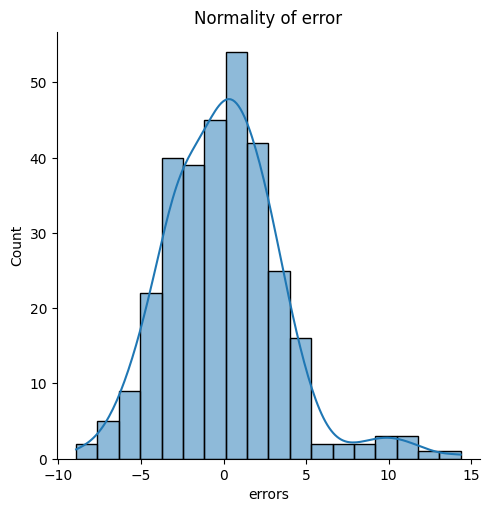

In [372]:
sns.displot(table['errors'],kde=True)
plt.title('Normality of error')

In [373]:
from scipy.stats import shapiro
stat, p_value = shapiro(table['errors'])

print(f"stat = {stat}, p_value = {p_value}")

if p_value > 0.05:
    print('Probably Normal Distribution')
else:
    print('Probably not Normal Distribution')

stat = 0.9686571915223438, p_value = 2.624154105343696e-06
Probably not Normal Distribution
